<a href="https://colab.research.google.com/github/aawbed/kq-sales-order-intelligence/blob/main/notebooks/Model_1_Demand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛫 Model 1: SARIMAX Demand Forecasting
### KQ Water Bottling Plant (Project Kifaru) — Machine Learning Intelligence
---
**Objective:** Predict future bulk water demand.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
print("Libraries successfully imported!")

Libraries successfully imported!


## 1. Load Dataset from GitHub
We extract the historical transactional logs directly from the system's database CSV export.

In [2]:
dataset_url = "https://raw.githubusercontent.com/aawbed/kq-sales-order-intelligence/main/kq_historical_sales_2025_2026.csv"
df_orders = pd.read_csv(dataset_url)

df_orders['date'] = pd.to_datetime(df_orders['Date'])
df_orders = df_orders.rename(columns={
    'Order ID': 'order_id',
    'Customer Name': 'customer_name',
    'Account Type': 'account_type',
    'Product Name': 'product_name',
    'Quantity': 'quantity',
    'Unit Price (KSh)': 'unit_price_kes',
    'Total Amount (KSh)': 'total_amount_kes',
    'Total Litres': 'total_litres'
})

print(f"Dataset successfully loaded!\nTotal Records: {len(df_orders)}")
df_orders.head()

Dataset successfully loaded!
Total Records: 761


,order_id,Date,customer_name,account_type,product_name,quantity,unit_price_kes,total_amount_kes,total_litres,date
0,KQ-251,2026-03-19,Customer 15,Distributor,250ml Cups Case (48 Pack),40,960.0,38400.0,480.0,2026-03-19
1,KQ-251,2026-03-19,Customer 15,Distributor,10L Bulk Dispenser Box,12,900.0,10800.0,120.0,2026-03-19
2,KQ-252,2026-03-30,Customer 2,Corporate Client,Premium Glass 500ml (12 Pack),2,3600.0,7200.0,12.0,2026-03-30
3,KQ-252,2026-03-30,Customer 2,Corporate Client,Premium Glass 500ml (12 Pack),38,3600.0,136800.0,228.0,2026-03-30
4,KQ-252,2026-03-30,Customer 2,Corporate Client,Flavored Water 500ml Case (24 Pack),37,1440.0,53280.0,444.0,2026-03-30


## 2. Model Training & Evaluation

Training SARIMAX model...

Validation MAE: 2683.87 Litres
Validation RMSE: 4558.08 Litres



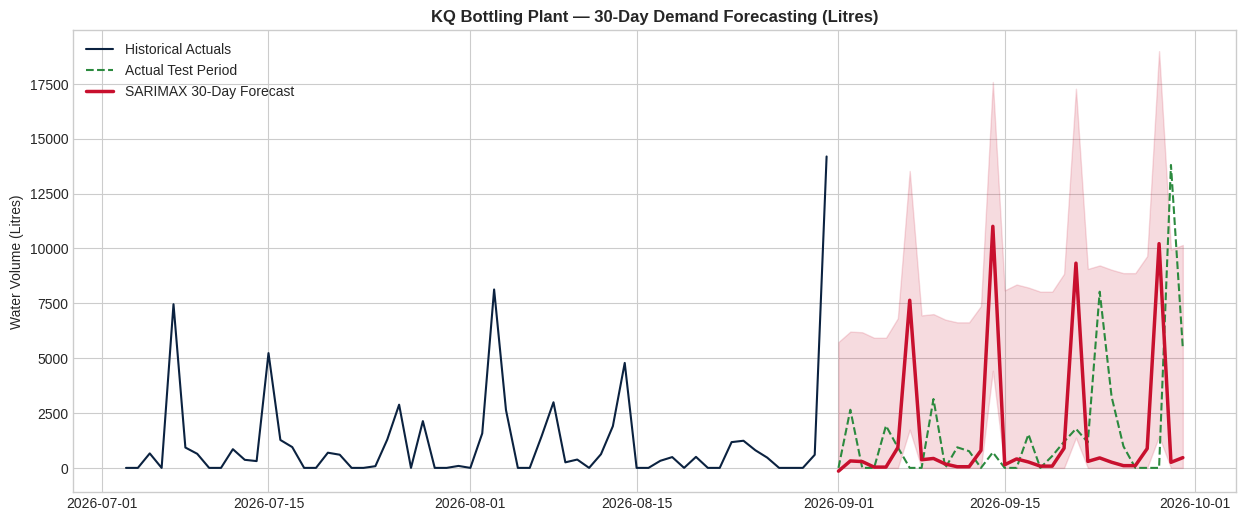

In [3]:
# Prepare daily time-series
df_daily = df_orders.groupby('date')['total_litres'].sum().reset_index()
df_daily = df_daily.set_index('date').asfreq('D', fill_value=0)

# Train/Validation Split (Last 30 days as validation)
train_data = df_daily[:-30]
val_data = df_daily[-30:]

print("Training SARIMAX model...")
sarimax_model = SARIMAX(
    train_data['total_litres'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
model_fit = sarimax_model.fit(disp=False)

# Predict
val_pred = model_fit.get_forecast(steps=30)
pred_mean = val_pred.predicted_mean
conf_int = val_pred.conf_int()

# Evaluate
mae = mean_absolute_error(val_data['total_litres'], pred_mean)
rmse = np.sqrt(mean_squared_error(val_data['total_litres'], pred_mean))
print(f"\nValidation MAE: {mae:.2f} Litres")
print(f"Validation RMSE: {rmse:.2f} Litres\n")

# Plot
plt.figure(figsize=(15, 6))
plt.plot(train_data.index[-60:], train_data['total_litres'][-60:], label='Historical Actuals', color='#0b2240')
plt.plot(val_data.index, val_data['total_litres'], label='Actual Test Period', color='#2b8a3e', linestyle='--')
plt.plot(val_data.index, pred_mean, label='SARIMAX 30-Day Forecast', color='#c8102e', lw=2.5)
plt.fill_between(val_data.index, np.maximum(0, conf_int.iloc[:, 0]), conf_int.iloc[:, 1], color='#c8102e', alpha=0.15)
plt.title("KQ Bottling Plant — 30-Day Demand Forecasting (Litres)", fontweight='bold')
plt.ylabel("Water Volume (Litres)")
plt.legend()
plt.show()